[*********************100%***********************]  1 of 1 completed


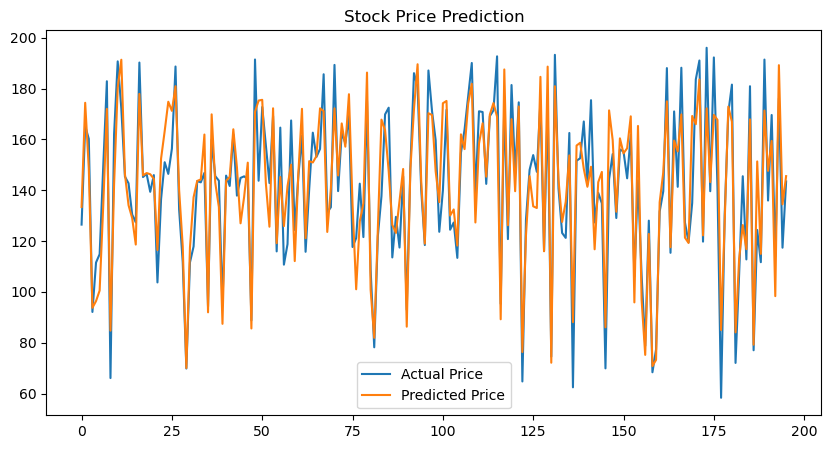

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

data = data[['Close']]

data['Prediction'] = data['Close'].shift(-30)

X = np.array(data.drop(['Prediction'], axis=1))[:-30]
y = np.array(data['Prediction'])[:-30]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()